# Modelos

## Sarima (estadistico) vs. XGBoost, Random Forest, y Gradient Boosting (ML)

Entrenamos un modelo estadistico y 3 modelos de machine learning sobre la serie semanal "Frontier Elo" y sus features, respetando el split temporal definido en `01_preprocesamiento.ipynb`

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

TEST_SIZE = 12

## Cargar datos preprocesados

In [2]:
serie = pd.read_csv('../data/serie_semanal.csv', index_col=0, parse_dates=True)['elo_max']
feat = pd.read_csv('../data/features_semanal.csv', index_col=0, parse_dates=True)

train_serie = serie.iloc[:-TEST_SIZE]
test_serie = serie.iloc[-TEST_SIZE:]

train_feat = feat.iloc[:-TEST_SIZE]
test_feat = feat.iloc[-TEST_SIZE:]

print(f"Serie completa: {len(serie)} obs | Train: {len(train_serie)} | Test: {len(test_serie)}")

Serie completa: 166 obs | Train: 154 | Test: 12


### Modelo Estadistico: SARIMA

Usamos `pmdarima.auto_arima` para seleccionar automaticamente el mejor orde (p,d,q)(P,D,Q,s) segun AIC, sobre la serie de entrenamiento

In [3]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train_serie,
    seasonal=True, m=52,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=1, max_Q=1,
    d=None, D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=1210.625, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=1210.629, Time=0.86 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=1209.986, Time=0.75 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=1215.378, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=1208.262, Time=0.05 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=1210.012, Time=0.59 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=3.10 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=1210.112, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[52] intercept   : AIC=1210.012, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=1208.837, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[52] intercept   : AIC=1211.955, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[52]             : AIC=1215.625, Time=0.03 sec

Best model:  ARIMA(0,1,1)(0,0,0)[52] intercept
Total fit time: 5.852 seconds
                               SARIMAX Results                                
D

In [4]:
sarima_forecast, sarima_ci = auto_model.predict(n_periods=TEST_SIZE, return_conf_int=True)
sarima_forecast = pd.Series(sarima_forecast, index=test_serie.index, name='sarima_pred')

sarima_forecast.head()

leaderboard_publish_date
2026-04-26    1503.084361
2026-05-03    1505.748532
2026-05-10    1508.412703
2026-05-17    1511.076874
2026-05-24    1513.741045
Name: sarima_pred, dtype: float64

### Modelos de ML: XGBoost, Random Forest y gradient boosting

Los 3 modelos usan las misma features y el mismo esquema de forecasting recursivo: predicen un paso a la vez y usan sus propias predicciones para recalcular los lags del siguiente paso. Esto permite una comparacion justa entre los 3, aislando el efecto del algoritmo

In [5]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

FEATURE_COLS = ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12',
                'roll_mean_4', 'roll_mean_12', 'roll_std_4',
                'week_sin', 'week_cos', 't']

X_train = train_feat[FEATURE_COLS]
y_train = train_feat['elo_max']

ml_models = {
    'xgb': XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    ),
    'rf': RandomForestRegressor(
        n_estimators=300, max_depth=5, min_samples_leaf=2, random_state=42
    ),
    'gb': GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

for name, model in ml_models.items():
    model.fit(X_train, y_train)

In [6]:
def forecast_recursivo(model, serie_completa, test_index, n_train_feat):
    """Genera un pronostico recursivo a n pasos para un modelo ya entrenado."""
    history = serie_completa.iloc[:len(serie_completa) - len(test_index)].copy()
    preds = []

    for i, date in enumerate(test_index):
        row = {}
        row['lag_1'] = history.iloc[-1]
        row['lag_2'] = history.iloc[-2]
        row['lag_4'] = history.iloc[-4]
        row['lag_8'] = history.iloc[-8]
        row['lag_12'] = history.iloc[-12]
        row['roll_mean_4'] = history.iloc[-4:].mean()
        row['roll_mean_12'] = history.iloc[-12:].mean()
        row['roll_std_4'] = history.iloc[-4:].std()
        week = date.isocalendar()[1]
        row['week_sin'] = np.sin(2 * np.pi * week / 52)
        row['week_cos'] = np.cos(2 * np.pi * week / 52)
        row['t'] = n_train_feat + i

        X_step = pd.DataFrame([row])[FEATURE_COLS]
        pred = model.predict(X_step)[0]
        preds.append(pred)
        history = pd.concat([history, pd.Series([pred], index=[date])])

    return pd.Series(preds, index=test_index)

forecasts_ml = {}
for name, model in ml_models.items():
    forecasts_ml[name] = forecast_recursivo(model, serie, test_serie.index, len(train_feat))

xgb_forecast = forecasts_ml['xgb'].rename('xgb_pred')
rf_forecast = forecasts_ml['rf'].rename('rf_pred')
gb_forecast = forecasts_ml['gb'].rename('gb_pred')

pd.DataFrame({'xgb': xgb_forecast, 'rf': rf_forecast, 'gb': gb_forecast}).head()


,xgb,rf,gb
leaderboard_publish_date,,,
2026-04-26,1495.937378,1498.101053,1498.288032
2026-05-03,1501.561157,1501.069195,1502.804086
2026-05-10,1500.989624,1501.292646,1502.603523
2026-05-17,1501.296753,1501.270838,1502.640212
2026-05-24,1500.337158,1500.757308,1497.938671


### Comparacion visual: las 4 predicciones vs. valores reales

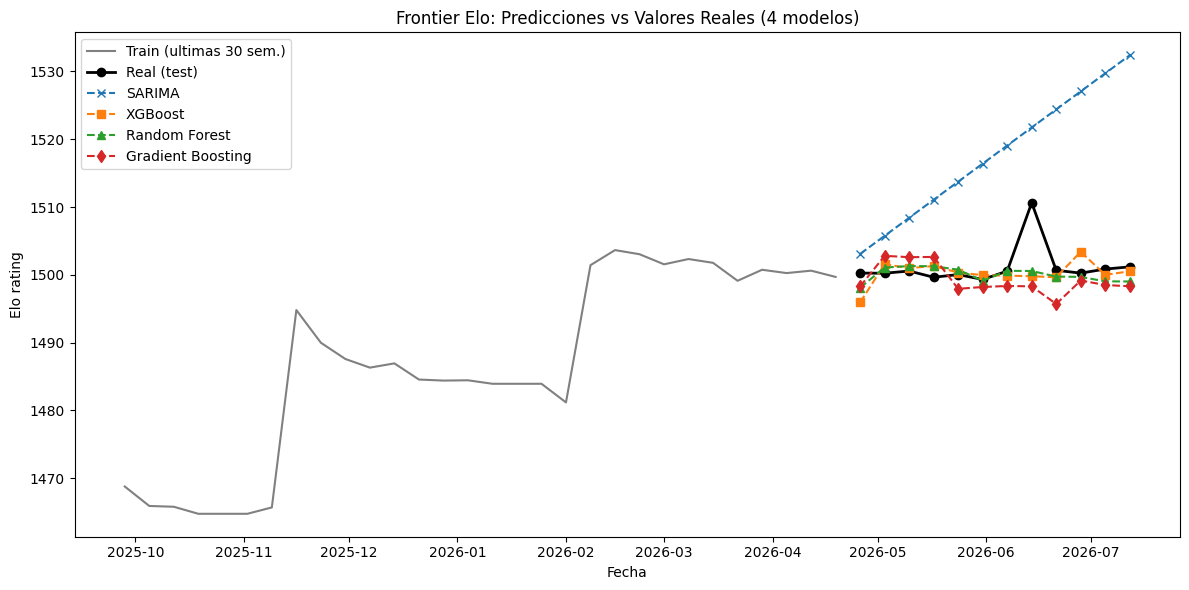

In [7]:
fig, ax = plt.subplots()
ax.plot(train_serie.index[-30:], train_serie.iloc[-30:], label='Train (ultimas 30 sem.)', color='gray')
ax.plot(test_serie.index, test_serie.values, label='Real (test)', color='black', marker='o', linewidth=2)
ax.plot(sarima_forecast.index, sarima_forecast.values, label='SARIMA', linestyle='--', marker='x')
ax.plot(xgb_forecast.index, xgb_forecast.values, label='XGBoost', linestyle='--', marker='s')
ax.plot(rf_forecast.index, rf_forecast.values, label='Random Forest', linestyle='--', marker='^')
ax.plot(gb_forecast.index, gb_forecast.values, label='Gradient Boosting', linestyle='--', marker='d')
ax.set_title('Frontier Elo: Predicciones vs Valores Reales (4 modelos)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Elo rating')
ax.legend()
plt.tight_layout()
plt.savefig('../results/04_predicciones_vs_reales.png', dpi=120)
plt.show()

### Guardar las prediciiones para el notebook de evaluacion

In [8]:
out = pd.DataFrame({
    'real': test_serie,
    'sarima_pred': sarima_forecast,
    'xgb_pred': xgb_forecast,
    'rf_pred': rf_forecast,
    'gb_pred': gb_forecast,
})
out.to_csv('../results/predicciones.csv')
out

,real,sarima_pred,xgb_pred,rf_pred,gb_pred
leaderboard_publish_date,,,,,
2026-04-26,1500.255186,1503.084361,1495.937378,1498.101053,1498.288032
2026-05-03,1500.237599,1505.748532,1501.561157,1501.069195,1502.804086
2026-05-10,1500.560585,1508.412703,1500.989624,1501.292646,1502.603523
2026-05-17,1499.640926,1511.076874,1501.296753,1501.270838,1502.640212
2026-05-24,1500.036179,1513.741045,1500.337158,1500.757308,1497.938671
2026-05-31,1499.317340,1516.405216,1499.950928,1499.119916,1498.204383
2026-06-07,1500.547773,1519.069387,1499.887207,1500.590447,1498.354397
2026-06-14,1510.631267,1521.733558,1499.787231,1500.566943,1498.301269
2026-06-21,1500.668125,1524.397729,1499.647217,1499.740425,1495.703294
